In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('bankloans.csv')

In [ ]:
df.shape

(1150, 9)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1150 entries, 0 to 1149
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1150 non-null   int64  
 1   ed        1150 non-null   int64  
 2   employ    1150 non-null   int64  
 3   address   1150 non-null   int64  
 4   income    1150 non-null   int64  
 5   debtinc   1150 non-null   float64
 6   creddebt  1150 non-null   float64
 7   othdebt   1150 non-null   float64
 8   default   700 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 81.0 KB


In [ ]:
df.isnull().sum()

,0
age,0
ed,0
employ,0
address,0
income,0
debtinc,0
creddebt,0
othdebt,0
default,450


In [ ]:
df = df.dropna()

In [ ]:
df.describe()

,age,ed,employ,address,income,debtinc,creddebt,othdebt,default
count,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000
mean,34.860000,1.722857,8.388571,8.278571,45.601429,10.260571,1.553553,3.058209,0.261429
std,7.997342,0.928206,6.658039,6.824877,36.814226,6.827234,2.117197,3.287555,0.439727
min,20.000000,1.000000,0.000000,0.000000,14.000000,0.400000,0.011696,0.045584,0.000000
25%,29.000000,1.000000,3.000000,3.000000,24.000000,5.000000,0.369059,1.044178,0.000000
50%,34.000000,1.000000,7.000000,7.000000,34.000000,8.600000,0.854869,1.987567,0.000000
75%,40.000000,2.000000,12.000000,12.000000,55.000000,14.125000,1.901955,3.923065,1.000000
max,56.000000,5.000000,31.000000,34.000000,446.000000,41.300000,20.561310,27.033600,1.000000


In [ ]:
#Data Cleanining
df.duplicated().sum()

np.int64(0)

In [ ]:
df = df.drop_duplicates()

In [ ]:
#Dropping Unrelated Columns
df = df.drop('address', axis=1)

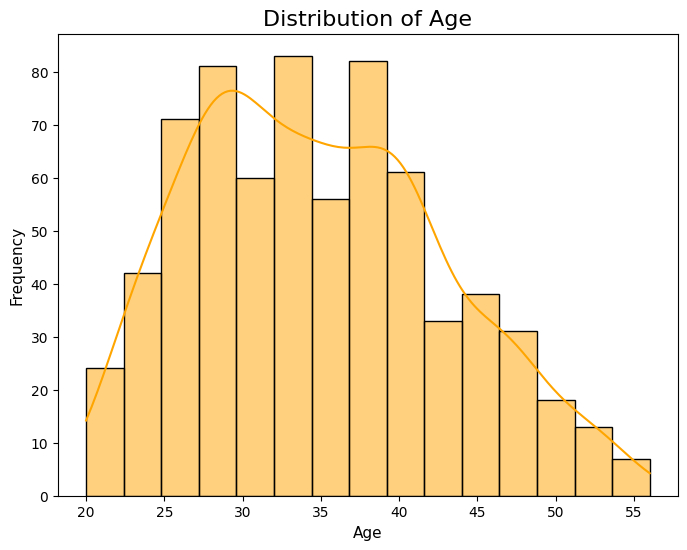

In [ ]:
#Univariate Analysis
plt.figure(figsize=(8,6))
sns.histplot(data=df,x=df["age"], kde=True, color='orange')
plt.title('Distribution of Age', fontsize=16)
plt.xlabel('Age', fontsize=11)
plt.ylabel('Frequency', fontsize=11)
plt.show()

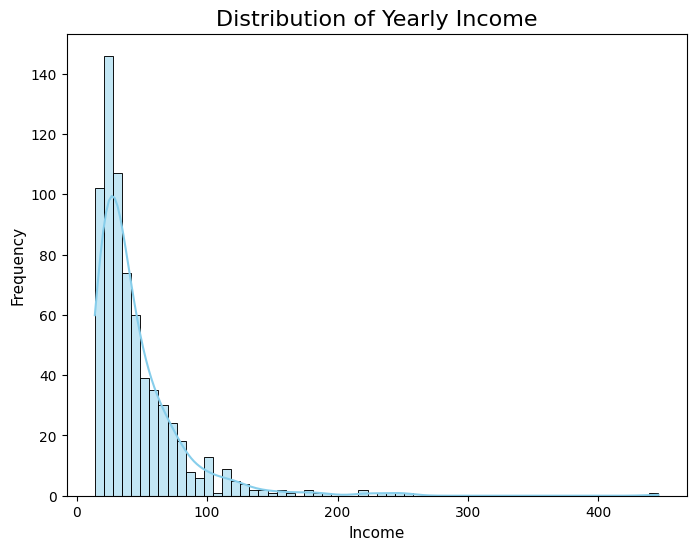

In [ ]:
plt.figure(figsize=(8,6))
sns.histplot(data=df,x=df["income"], kde=True, color='skyblue')
plt.title('Distribution of Yearly Income', fontsize=16)
plt.xlabel('Income', fontsize=11)
plt.ylabel('Frequency', fontsize=11)
plt.show()

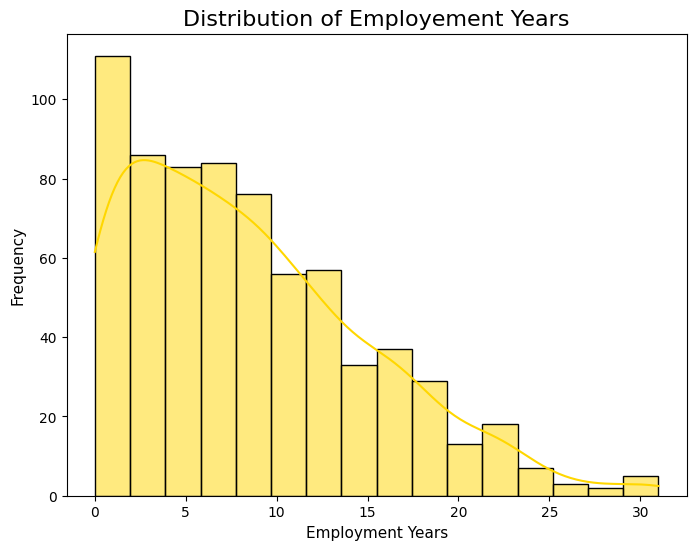

In [ ]:
plt.figure(figsize=(8,6))
sns.histplot(data=df,x=df["employ"], kde=True, color='gold')
plt.title('Distribution of Employement Years', fontsize=16)
plt.xlabel('Employment Years', fontsize=11)
plt.ylabel('Frequency', fontsize=11)
plt.show()

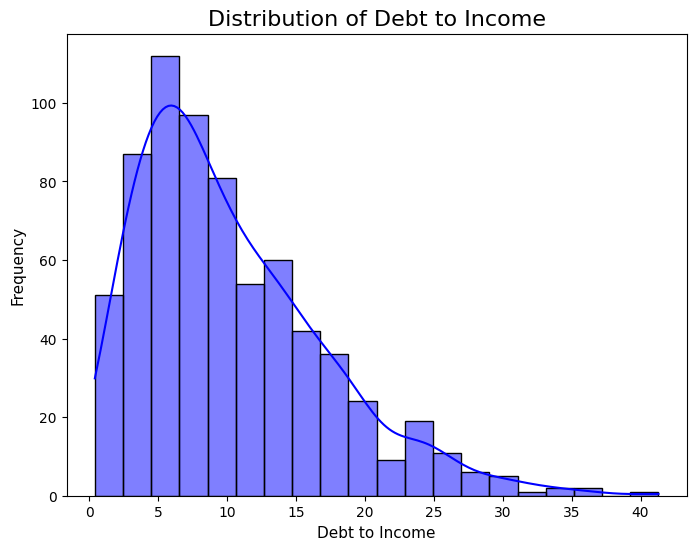

In [ ]:
plt.figure(figsize=(8,6))
sns.histplot(data=df,x=df["debtinc"], kde=True, color='blue')
plt.title('Distribution of Debt to Income', fontsize=16)
plt.xlabel('Debt to Income', fontsize=11)
plt.ylabel('Frequency', fontsize=11)
plt.show()

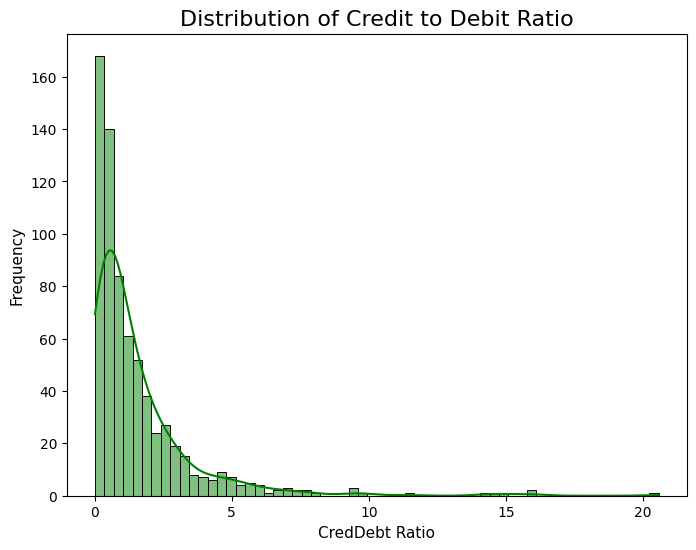

In [ ]:
plt.figure(figsize=(8,6))
sns.histplot(data=df,x=df["creddebt"], kde=True, color='green')
plt.title('Distribution of Credit to Debit Ratio', fontsize=16)
plt.xlabel('CredDebt Ratio', fontsize=11)
plt.ylabel('Frequency', fontsize=11)
plt.show()

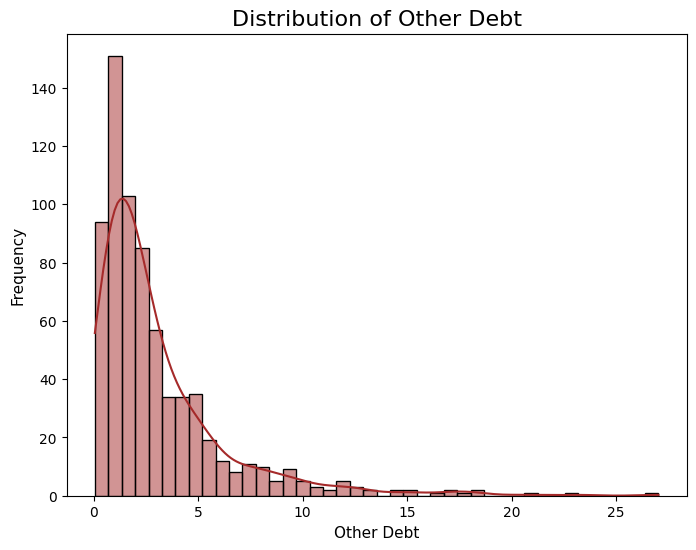

In [ ]:
plt.figure(figsize=(8,6))
sns.histplot(data=df,x=df["othdebt"], kde=True, color='brown')
plt.title('Distribution of Other Debt', fontsize=16)
plt.xlabel('Other Debt', fontsize=11)
plt.ylabel('Frequency', fontsize=11)
plt.show()

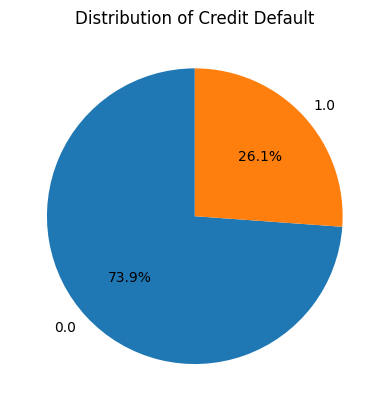

In [ ]:
default_counts = df['default'].value_counts()
plt.pie(default_counts, labels=default_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Credit Default')
plt.show()

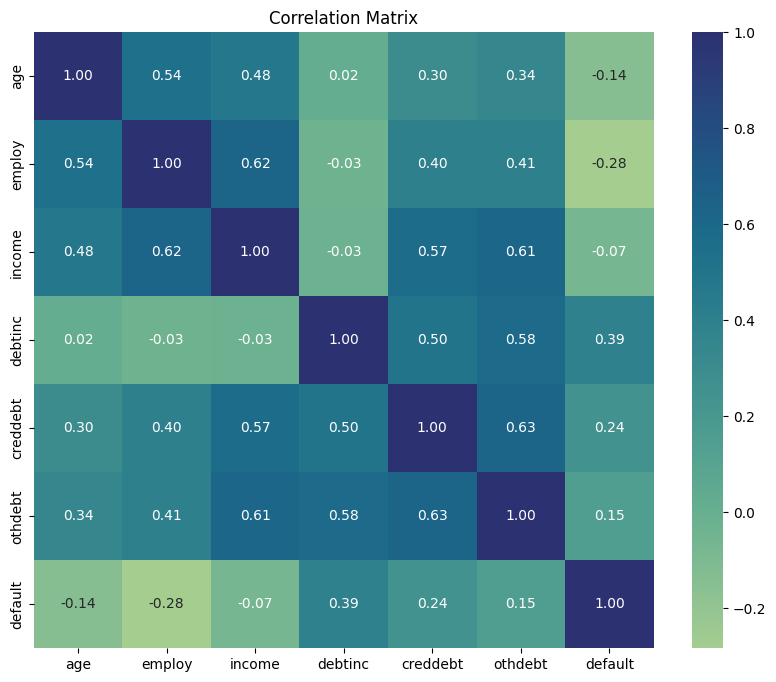

In [ ]:
#Multivariate Analysis
variables = ['age', 'employ', 'income', 'debtinc', 'creddebt', 'othdebt', 'default']

correlation_matrix = df[variables].corr()

plt.figure(figsize=(10,8))
sns.heatmap(correlation_matrix, annot=True, cmap='crest', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

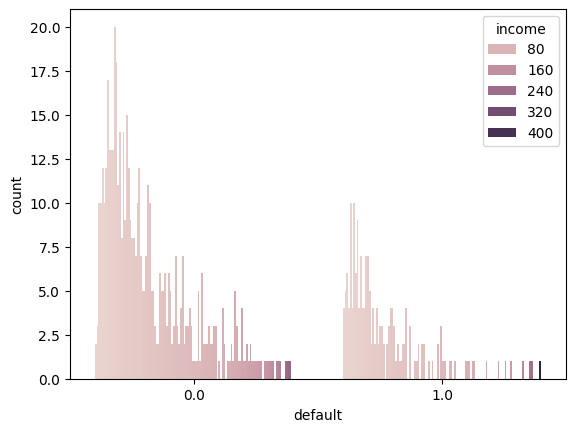

In [ ]:
for i, predictor in enumerate(df[["default",]].columns):
    plt.figure(i)
    sns.countplot(data=df, x=predictor, hue='income')

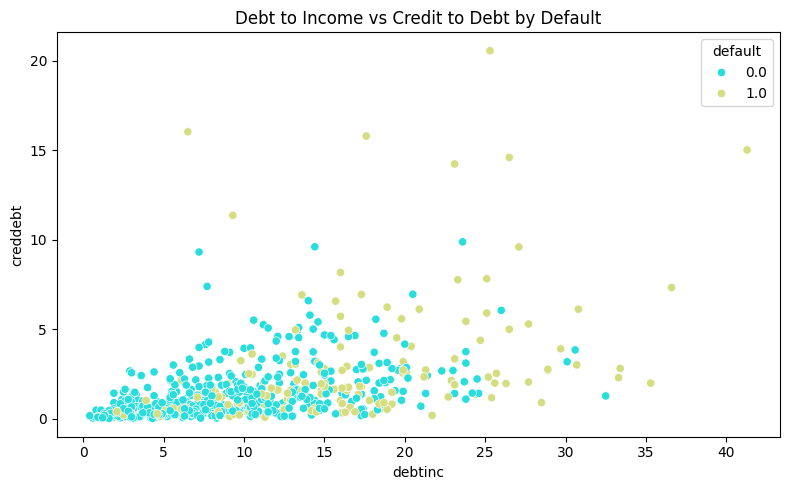

In [ ]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='debtinc', y='creddebt', hue='default', palette='rainbow')
plt.title('Debt to Income vs Credit to Debt by Default')
plt.xlabel('debtinc')
plt.ylabel('creddebt')
plt.legend(title='default')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, confusion_matrix, ConfusionMatrixDisplay, classification_report,  accuracy_score, precision_score, recall_score, f1_score

Logistic Regression

In [ ]:
# Define features and target
features = ['age', 'ed', 'employ','income', 'debtinc', 'creddebt', 'othdebt']
target = 'default'

In [ ]:
X = df[features]
y = df[target]

nan_indices = y[y.isna()].index
X = X.drop(nan_indices)
y = y.drop(nan_indices)

In [ ]:
#splitting the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Initialize the Logistic Regression model
classifier = LogisticRegression(max_iter=1000)

#train the model
classifier.fit(X_train, y_train)
#make prediciton
y_pred = classifier.predict(X_test)

In [ ]:
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")

y_pred = classifier.predict(X_test)
print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.87
Precision: 0.92
Recall: 0.58
F1-Score: 0.71
Classification Report:
              precision    recall  f1-score   support

         0.0       0.86      0.98      0.92       102
         1.0       0.92      0.58      0.71        38

    accuracy                           0.87       140
   macro avg       0.89      0.78      0.81       140
weighted avg       0.88      0.87      0.86       140



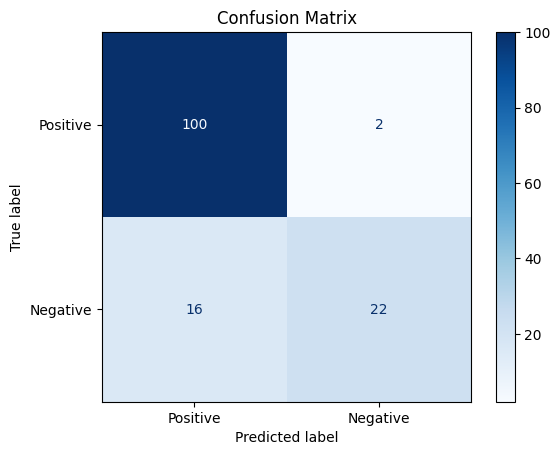

In [ ]:
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])

disp = ConfusionMatrixDisplay (confusion_matrix=cm, display_labels = ['Positive','Negative'] )
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

Linear Regression

In [ ]:
features = ['age', 'ed', 'employ','income']
target = 'debtinc'

In [ ]:
X = df[features]
y = df[target]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [ ]:
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
print(f'R-squared: {r2:.4f}')
print(f'Mean Squared Error: {mse:.4f}')

R-squared: -0.0384
Mean Squared Error: 47.6775


In [ ]:
for feature, coef in zip(features, model.coef_):
    print(f'Coefficient for {feature}: {coef:.4f}')

Coefficient for age: 0.0693
Coefficient for ed: -0.0999
Coefficient for employ: -0.0998
Coefficient for income: -0.0057


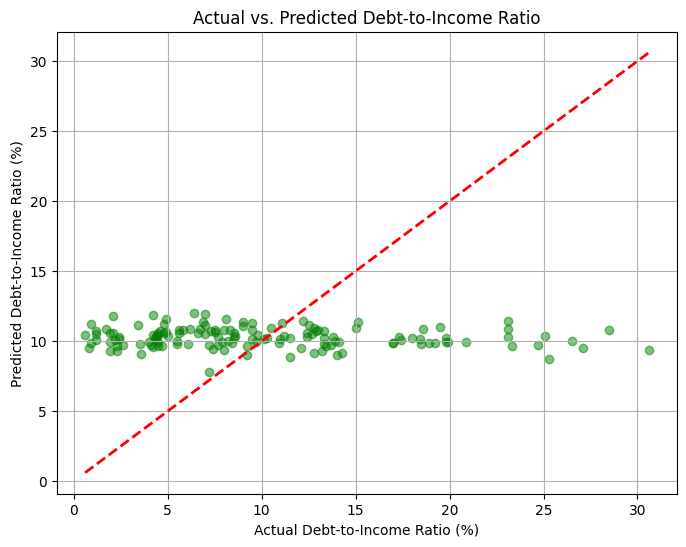

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Debt-to-Income Ratio (%)')
plt.ylabel('Predicted Debt-to-Income Ratio (%)')
plt.title('Actual vs. Predicted Debt-to-Income Ratio')
plt.grid(True)
plt.show()

Hypothesis Testing

In [ ]:
from scipy import stats
defaulters = df[df['default'] == 1]['income']
non_defaulters = df[df['default'] == 0]['income']
t_stat, p_value = stats.ttest_ind(defaulters, non_defaulters, alternative='greater')
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")
if p_value < 0.05:
    print("Reject H0: Defaulters have significantly less mean income.")
else:
    print("Fail to reject H0: No significant difference in mean income.")

T-statistic: -1.8797
P-value: 0.9697
Fail to reject H0: No significant difference in mean income.


In [ ]:
!pip install nbconvert
!apt-get install texlive texlive-xetex texlive-latex-extra pandoc
!jupyter nbconvert --to pdf <notebook-name>.ipynb
from google.colab import drive
drive.mount("/content/drive")
!jupyter nbconvert --to pdf --output <output-filename>.pdf <notebook-name>.ipynb

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  dvisvgm fonts-droid-fallback fonts-lato fonts-lmodern fonts-noto-mono
  fonts-texgyre fonts-urw-base35 libapache-pom-java
  libcmark-gfm-extensions0.29.0.gfm.3 libcmark-gfm0.29.0.gfm.3
  libcommons-logging-java libcommons-parent-java libfontbox-java libgs9
  libgs9-common libidn12 libijs-0.35 libjbig2dec0 libkpathsea6 libpdfbox-java
  libptexenc1 libruby3.0 libsynctex2 libteckit0 libtexlua53 libtexluajit2
  libwoff1 libzzip-0-13 lmodern pandoc-data poppler-data preview-latex-style
  rake ruby ruby-net-telnet ruby-rubygems ruby-webrick ruby-xmlrpc ruby3.0
  rubygems-integration t1utils teckit tex-common tex-gyre texlive-base
  texlive-binaries texlive-fonts-recommended texlive-latex-base
  texlive-latex-recommended texlive-pictures texlive-plain-generic tipa
  xfonts-encodings xfonts-utils
Suggested packages:
  fonts-noto fonts-freefont-